In [1]:
import numpy as np
import pandas as pd
import zarr
import os
import matplotlib.pyplot as plt
plt.style.use('../libs/my_style.mplstyle')

import os
import sys

sys.path.append(os.path.abspath(".."))

folder = '/Volumes/My Passport/Sasaki/MTsingleBeads'

track_path = 'MTtrack.csv'

path0 = os.path.join(folder, "20260121/beads_trans_crop_crop", track_path)
path1 = os.path.join(folder, "20260121/exp_crop1", track_path)
path2 = os.path.join(folder, "20260122/exp", track_path)
path3 = os.path.join(folder, "20260122/exp001", track_path)
path4 = os.path.join(folder, "20260122/exp002", track_path)

def vec(df):
    # 1. 前処理: frameでソートしておく（groupby内での処理を減らすため）
    df = df.sort_values(['particle', 'frame'])

    # 2. 差分計算（各グループの最初の一行はNaNになる）
    # diff() は pandas のメソッドを使うとインデックスが維持されるので安全です
    dx = df.groupby('particle')['x'].diff()
    dy = df.groupby('particle')['y'].diff()

    # 3. 速度ベクトルと単位ベクトルの計算
    v = np.sqrt(dx**2 + dy**2)

    df['theta'] = dx/v + 1j * dy/v

    return df

def calculate_polar_order(df):
    """
    各フレームごとのポーラー度（Order Parameter）を算出する
    """
    # 1. 各フレームごとに複素ベクトルの平均を取る
    # thetaには既に単位ベクトル（dx/v + i*dy/v）が入っている前提
    group_avg = df.groupby('frame')['theta'].mean()
    
    # 2. 平均ベクトルの絶対値（長さ）を計算する
    # これが 1 に近いほど揃っており、0 に近いほどバラバラ
    polar_order = group_avg.abs()

    # 各フレームごとの粒子の数をカウント
    # 'theta' が NaN でないもの（速度が計算できているもの）だけを数えるのが実用的です
    counts = df.dropna(subset=['theta']).groupby('frame')['particle'].count()
    
    return polar_order, counts

paths = [path0, path1, path2, path3, path4]
labels = ['exp_0', 'exp_1', 'exp_2', 'exp_3', 'exp_4'] # 任意のラベル

polars_dict = {}
count_dict = {}

for path, label in zip(paths, labels):
    df_temp = pd.read_csv(path)
    df_temp = vec(df_temp)
    # calculate_polar_order の結果を辞書に格納
    polar_order, counts = calculate_polar_order(df_temp)
    polars_dict[label] = polar_order
    count_dict[label] = counts


# 辞書から一気にDataFrameを作成（frameがインデックスになります）
df_polar_all = pd.DataFrame(polars_dict)
df_count_all = pd.DataFrame(count_dict)

print(df_polar_all.head())
print(df_count_all.head())

          exp_0     exp_1     exp_2     exp_3     exp_4
frame                                                  
0           NaN       NaN       NaN       NaN       NaN
1      0.599807  0.422527  0.114960  0.288503  0.791554
2      0.998038  0.545340  0.195914  0.227181  0.567668
3      0.997901  0.498173  0.160361  0.184195  0.265805
4      0.775135  0.495311  0.100970  0.147998  0.307650
       exp_0  exp_1  exp_2  exp_3  exp_4
frame                                   
1        5.0   64.0   32.0   37.0    4.0
2        5.0   80.0   38.0   56.0    4.0
3        5.0   99.0   44.0   65.0    5.0
4        6.0  124.0   50.0   75.0    7.0
5        8.0  152.0   57.0   86.0    9.0


In [2]:
# 閾値を設定（例：粒子が10個未満のフレームは信頼しない）
threshold = 10

# df_polar_all と同じ形状の True/False マスクを作成
mask = df_count_all >= threshold

# マスクを適用：条件を満たさない（False）場所を NaN にする
df_polar_masked = df_polar_all.where(mask)

print(f"マスク前の有効データ数: {df_polar_all.count().sum()}")
print(f"マスク後の有効データ数: {df_polar_masked.count().sum()}")

マスク前の有効データ数: 1509
マスク後の有効データ数: 681


[(0.0, 1000.0),
 (0.0, 1.0),
 Text(0.5, 0, 'time $t$ [s]'),
 Text(0, 0.5, 'Polar order parameter')]

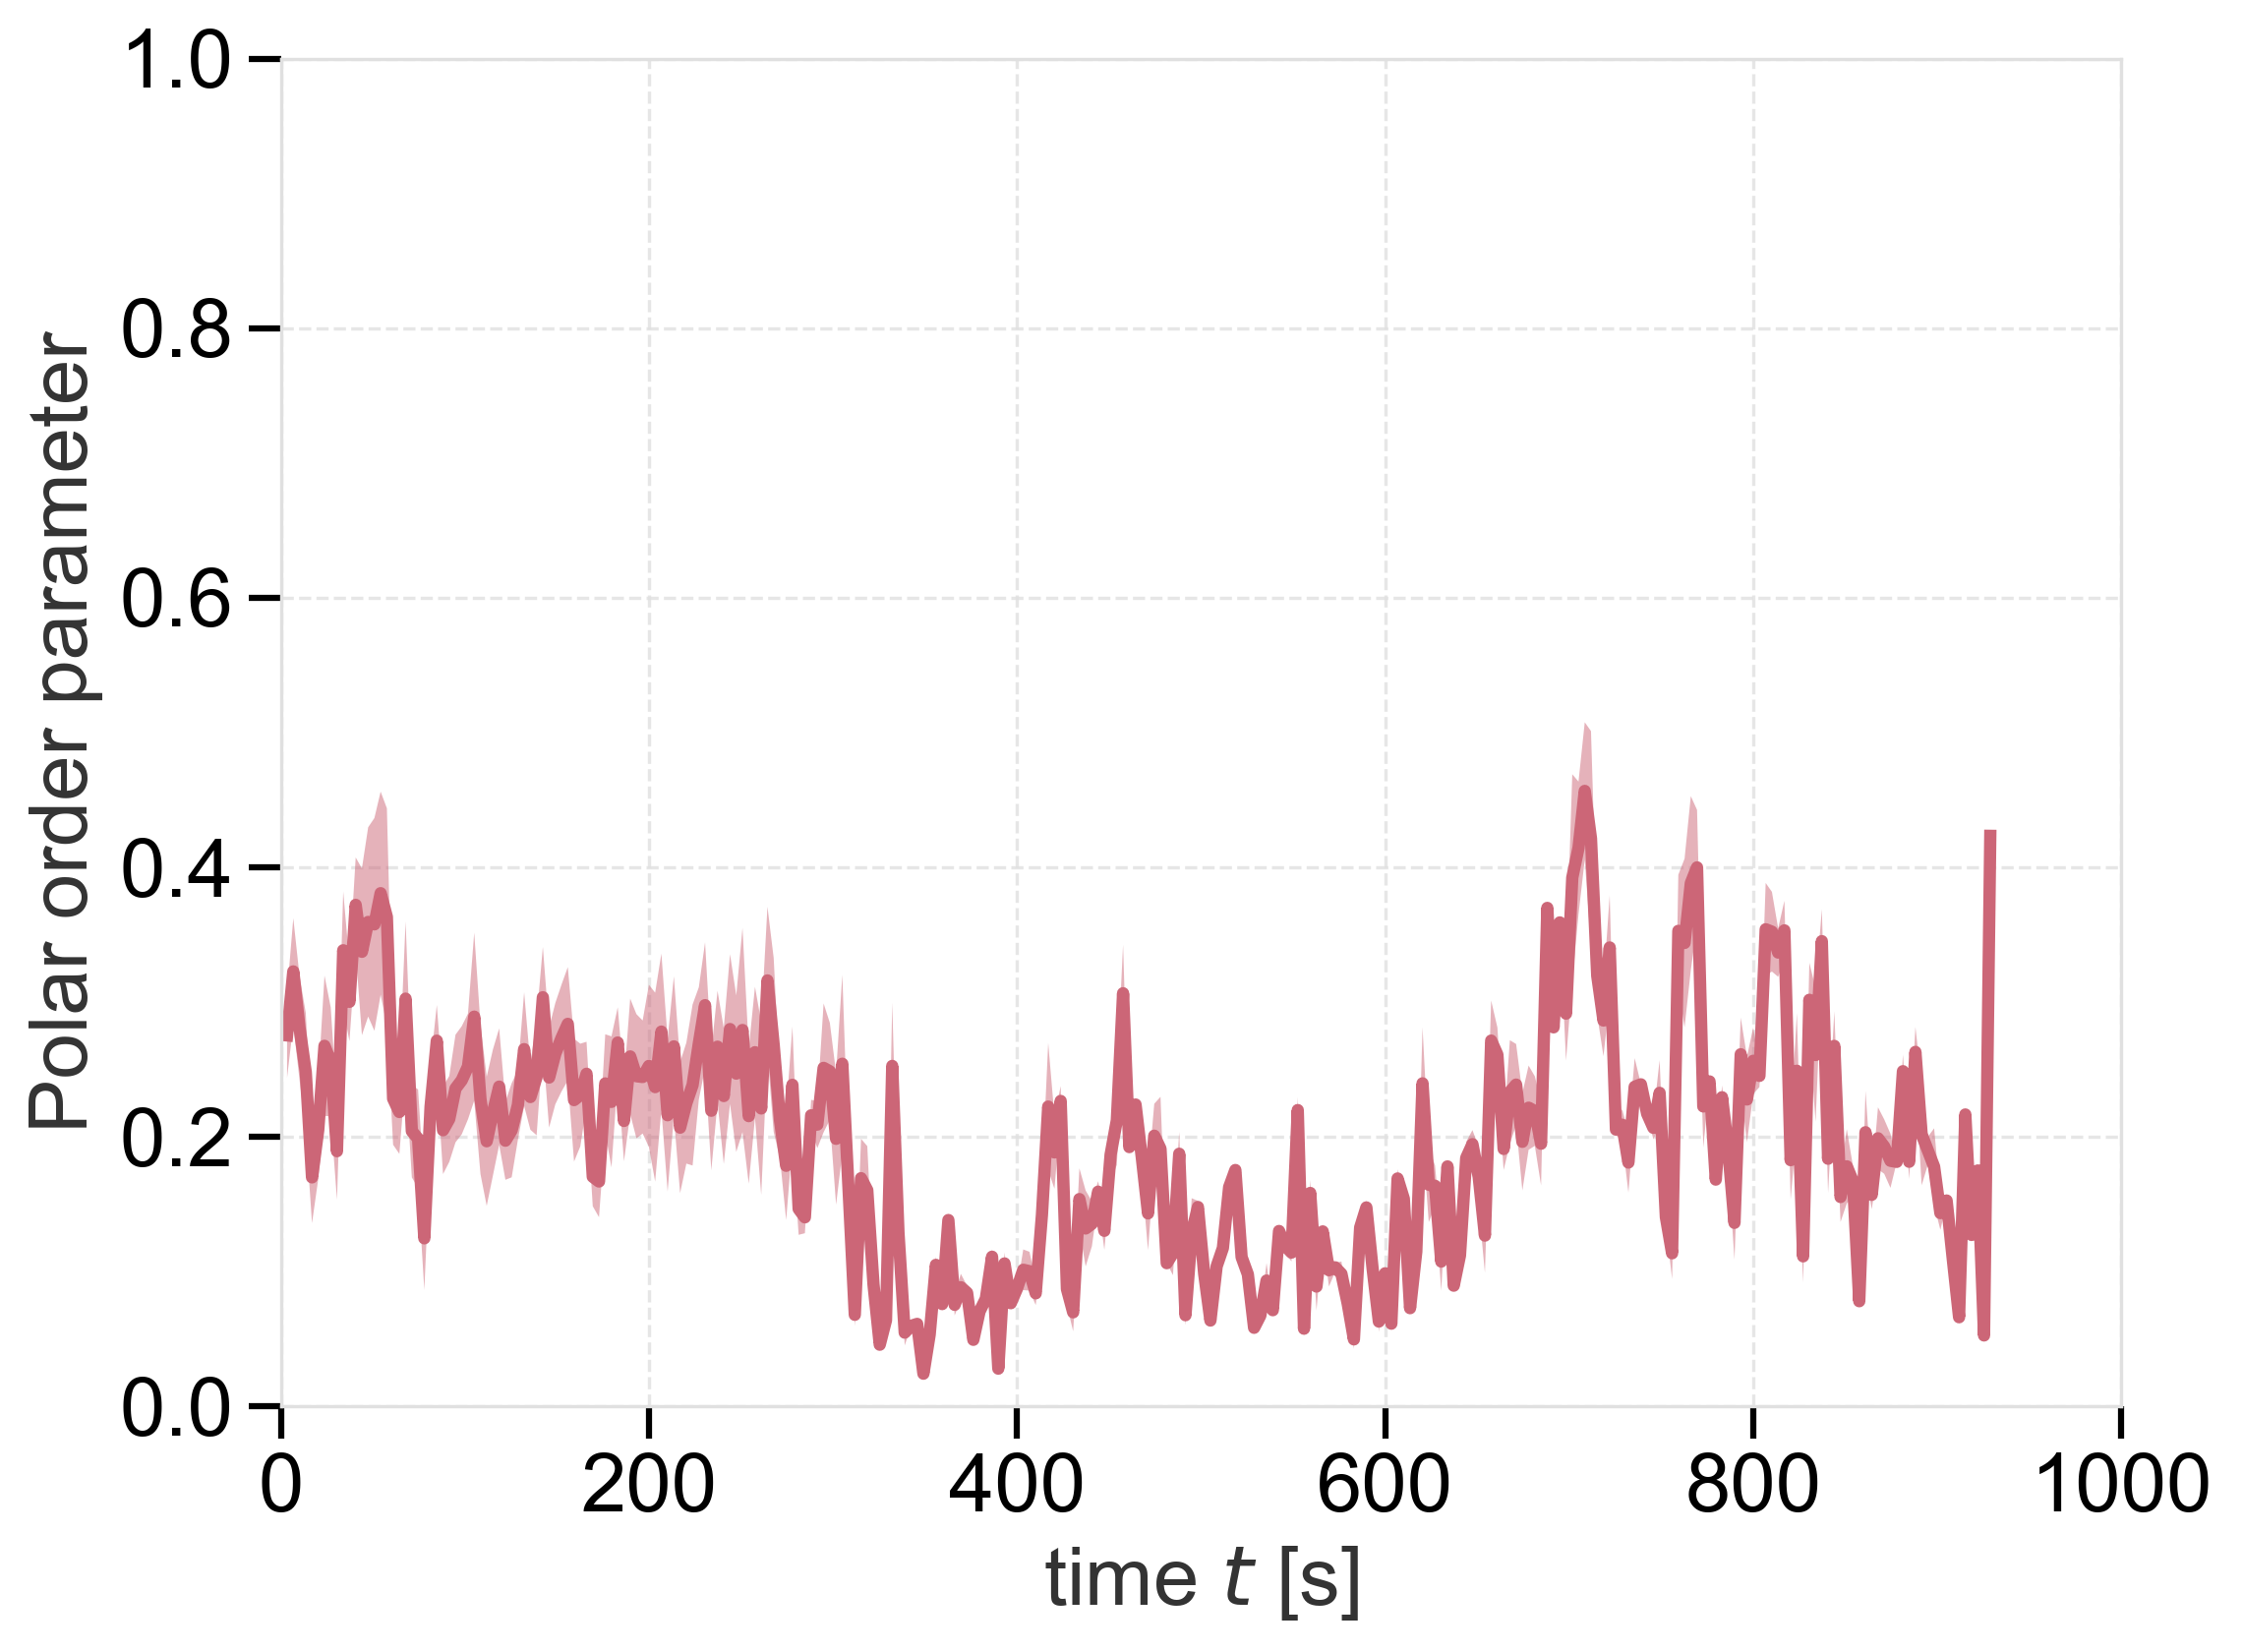

In [3]:
mean = np.mean(df_polar_masked, axis = 1)
sem = np.std(df_polar_masked, axis = 1)/4

tau = 1.18

fig, ax = plt.subplots()

ax.plot(np.arange(len(mean)) * 4/tau, mean)
ax.fill_between(np.arange(len(mean)) * 4/tau, mean - sem, mean + sem, alpha = 0.5)

ax.set(xlim = (0, 1000),
       ylim = (0, 1),
       xlabel = 'time $t$ [s]',
       ylabel = 'Polar order parameter')

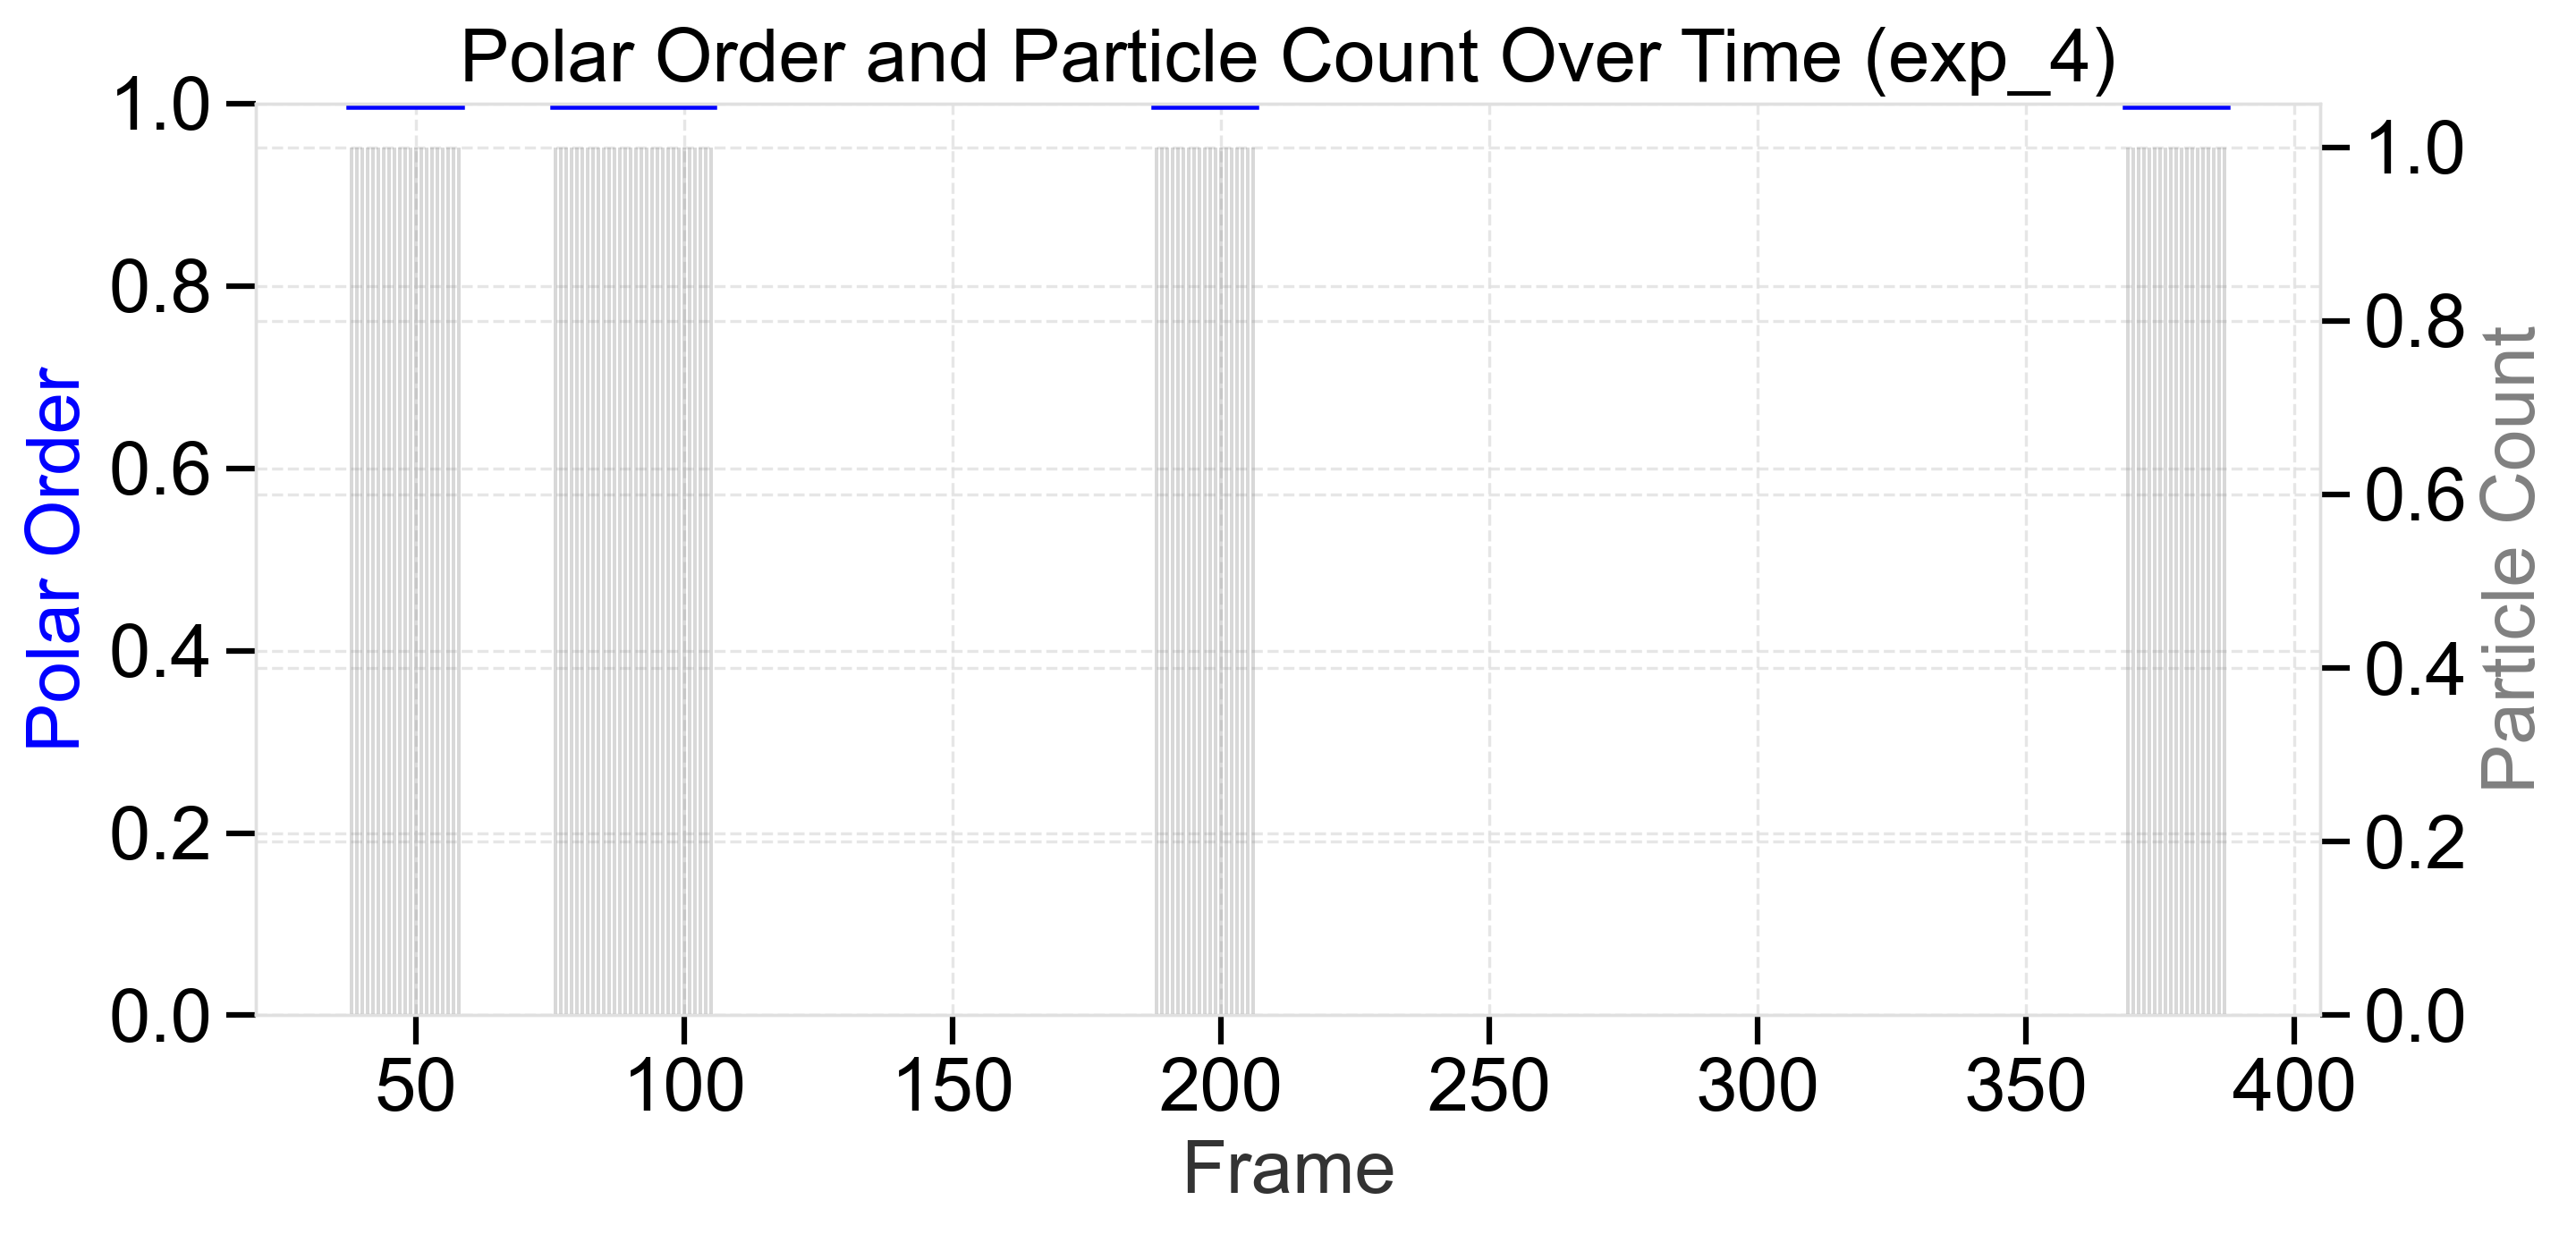

In [53]:
import matplotlib.pyplot as plt

exp_name = 'exp_4'

fig, ax1 = plt.subplots(figsize=(10, 5))

# 左軸：ポーラー度
ax1.plot(df_polar_all.index, df_polar_all[exp_name], color='blue', label='Polar Order')
ax1.set_xlabel('Frame')
ax1.set_ylabel('Polar Order', color='blue')
ax1.set_ylim(0, 1)

# 右軸：粒子数
ax2 = ax1.twinx()
ax2.bar(df_count_all.index, df_count_all[exp_name], color='gray', alpha=0.3, label='Particle Count')
ax2.set_ylabel('Particle Count', color='gray')

plt.title(f'Polar Order and Particle Count Over Time ({exp_name})')
plt.show()